# 数学建模综合实践

学习目标：把带噪声测量写成线性模型，连接最小二乘、梯度检查、参数区间与重复抽样，并用选学 PCA 核对投影和重构的关系。

前置知识：线性拟合、矩阵求导、参数估计、置信区间、浮点误差；Python 函数与 NumPy 数组。选学另需协方差、特征分解与 SVD。

运行环境：Python 3.12、NumPy 2.5、SciPy 1.18、Matplotlib 3.11；完整版本见环境说明。数据全部为教学构造或模拟，无外部数据、网络调用或真实仪器实验。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 从五次测量提出问题

设传感器输入为力 x，单位为牛顿（N）；输出为电压 y，单位为伏特（V）。希望在指定输入范围内，用直线描述平均输出。模型写为

$$Y_i=\beta_0+\beta_1x_i+\varepsilon_i,\qquad i=1,\ldots,n。$$

β₀ 是截距，单位 V；β₁ 是斜率，单位 V/N；εᵢ 是测量误差，单位 V。Yᵢ 是重复测量前的随机变量，小写 yᵢ 表示一次得到的数值。先取 n=5 个手工构造的数据，比较候选直线 y=1+2x 与观测的差。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

x_small = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_small = np.array([1.1, 2.9, 5.2, 6.8, 9.0])
candidate = 1.0 + 2.0 * x_small
print("候选直线输出（V）：", candidate)  # 预期为 [1. 3. 5. 7. 9.]。
print("观测减候选值（V）：", y_small - candidate)  # 预期约为 [ 0.1 -0.1 0.2 -0.2 0. ]。
# 输入增加 1 N，候选平均输出增加 2 V；各点偏差不完全相同。

候选直线输出（V）： [1. 3. 5. 7. 9.]
观测减候选值（V）： [ 0.1 -0.1  0.2 -0.2  0. ]


建模前先区分计算规则和统计假设。以下主线把输入 xᵢ 当作预先固定且无测量误差的数，输入至少有两个不同取值；参数在所有测量中保持不变。统计推断还假设误差独立、均值为零、方差同为 σ²>0，精确 t 区间进一步采用正态误差。

这些是本章模拟采用的条件，不能由拟合成功自动推出。若输入本身也有误差、输出呈弯曲趋势或误差随时间相关，需要重新考虑模型。下面只先检查输入是否能区分截距与斜率。

In [2]:
print("测量次数：", x_small.size)  # 预期为 5。
print("输入的不同取值数：", np.unique(x_small).size)  # 预期为 5。
print("输入范围（N）：", x_small.min(), x_small.max())  # 预期为 0 4。
# 这些输出检查设计条件，不检验误差的独立性或正态性。

测量次数： 5
输入的不同取值数： 5
输入范围（N）： 0.0 4.0


## 2 设计矩阵与形状

把 β=(β₀,β₁)ᵀ 写成 2×1 列向量，把 Y 和 ε 写成 n×1 列向量。设计矩阵 A 的第 i 行为 (1,xᵢ)，形状为 n×2，于是 Y=Aβ+ε。第一列的 1 无量纲，第二列保存以 N 为单位的输入数值；两列乘相应系数后都得到 V。

代码用形状 (2,) 和 (n,) 的一维数组保存向量；A @ beta 的结果为 (n,)，不是 (n,1)。以下先核对前两行：预测分别为 β₀ 和 β₀+β₁。

In [3]:
a_small = np.column_stack([np.ones(x_small.size), x_small])
beta_candidate = np.array([1.0, 2.0])
print("设计矩阵：\n", a_small)  # 预期为 [[1. 0.] [1. 1.] [1. 2.] [1. 3.] [1. 4.]]。
# 预期为 (5, 2) (2,) (5,)。
print(
    "A、beta、A@beta 的形状：",
    a_small.shape,
    beta_candidate.shape,
    (a_small @ beta_candidate).shape,
)
print("与逐项计算的最大差：", np.max(np.abs(a_small @ beta_candidate - candidate)))  # 预期接近 0；本次计算为 0。
# 两种表达完全相同；数学列向量与代码一维数组的布局需要分别说明。

设计矩阵：
 [[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]]
A、beta、A@beta 的形状： (5, 2) (2,) (5,)
与逐项计算的最大差： 0.0


## 3 最小二乘与正规方程

本章按统计回归约定，将残差定义为 $r=y-A\widehat\beta$（观测减拟合）。优化目标常使用相反方向的误差 $e(\beta)=A\beta-y$（预测减观测），因此 $r=-e(\widehat\beta)$。两者平方和相同，正交条件也等价；残差图中 r 为正表示观测高于拟合。最小二乘选择使平方残差和最小的参数。为方便求导，使用等价目标

$$L(\beta)=\frac{1}{2n}\|A\beta-y\|_2^2
=\frac{1}{2n}\left(\beta^TA^TA\beta-2\beta^TA^Ty+y^Ty\right)。$$

L 的单位为 V²。A 列满秩时，AᵀA 正定，唯一最小点满足正规方程 AᵀAβ̂=Aᵀy；等价地 Aᵀr=0。这里是残差与设计矩阵各列正交，残差本身通常不为零。

In [4]:
beta_small, _, rank_small, singular_small = np.linalg.lstsq(
    a_small, y_small, rcond=None
)
normal_small = np.linalg.solve(a_small.T @ a_small, a_small.T @ y_small)
residual_small = y_small - a_small @ beta_small
print("最小二乘系数（截距 V、斜率 V/N）：", beta_small)  # 预期约为 [1.06 1.97]。
print("正规方程结果：", normal_small)  # 预期约为 [1.06 1.97]。
print("系数最大差：", np.max(np.abs(beta_small - normal_small)))  # 本次数值约为 1.8e-15。
print("秩与 A.T@残差：", rank_small, a_small.T @ residual_small)  # 矩阵秩为 2；预期 A.T@残差 接近零，本次最大绝对分量约 2.2e-15。
print("平方残差和（V²）：", residual_small @ residual_small)  # 预期约为 0.091。
# 手算得到截距 1.06、斜率 1.97；正交残差应在舍入尺度附近。

最小二乘系数（截距 V、斜率 V/N）： [1.06 1.97]
正规方程结果： [1.06 1.97]
系数最大差： 1.7763568394002505e-15
秩与 A.T@残差： 2 [0.00000000e+00 2.22044605e-15]
平方残差和（V²）： 0.09100000000000015


对直线还可以直接计算。令 x̄、ȳ 分别为输入和输出的样本平均，Sxx=Σᵢ(xᵢ−x̄)²，则

$$\widehat\beta_1=\frac{\sum_i(x_i-\bar x)(y_i-\bar y)}{S_{xx}},\qquad
\widehat\beta_0=\bar y-\widehat\beta_1\bar x。$$

Sxx>0 等价于输入不全相同。这里的小矩阵可用正规方程核对代数；实际拟合直接调用 lstsq()，避免把“显式求逆”写成求解步骤。下面把手算式、NumPy 和 SciPy 的结果放在一起比较。

In [5]:
centered_small = x_small - x_small.mean()
sxx_small = centered_small @ centered_small
slope_small = centered_small @ (y_small - y_small.mean()) / sxx_small
intercept_small = y_small.mean() - slope_small * x_small.mean()
library_small = stats.linregress(x_small, y_small)
print("手算式：", intercept_small, slope_small)  # 预期约为 1.06 1.97。
print("SciPy：", library_small.intercept, library_small.slope)  # 预期约为 1.06 1.97。
print("Sxx（N²）：", sxx_small)  # 预期为 10。
# 三种计算针对同一个目标；一致性不能证明直线假设符合真实仪器。

手算式： 1.06 1.97
SciPy： 1.06 1.97
Sxx（N²）： 10.0


## 4 平方误差的梯度与差分检查

对第 j 个参数求偏导，j=0,1，对应 A 的两列：

$$\frac{\partial L}{\partial\beta_j}
=\frac1n\sum_{i=1}^n A_{ij}\left((A\beta)_i-y_i\right)。$$

合并为 2×1 梯度 ∇L=Aᵀ(Aβ−y)/n，Hessian 为 AᵀA/n。梯度两个分量的单位分别为 V 和 V·N，不能把有不同单位的分量直接解释为物理距离。本章仅在固定单位下核对各分量的数值。

这里用 $e(\beta)=A\beta-y$ 写梯度：$\nabla L=A^Te(\beta)/n$。若改用随参数变化的 $y-A\beta$，梯度前必须带负号；不能只替换残差名称而保留原符号。

In [6]:
def loss(beta, design, observed):
    # 返回给定数值单位下的半均方残差。
    difference = design @ beta - observed
    return difference @ difference / (2 * observed.size)


trial_beta = np.array([0.8, 1.4])
gradient = a_small.T @ (a_small @ trial_beta - y_small) / y_small.size
hessian = a_small.T @ a_small / y_small.size
print("试探点的损失（V²）：", loss(trial_beta, a_small, y_small))  # 预期约为 1.314。
print("解析梯度：", gradient)  # 预期约为 [-1.4 -3.94]。
print("Hessian：\n", hessian)  # 预期为 [[1. 2.] [2. 6.]]。
print("拟合点的梯度：", a_small.T @ (a_small @ beta_small - y_small) / y_small.size)  # 预期拟合点的梯度接近零向量；本次最大分量绝对值约 4.4e-16。
# 试探点的梯度不为零；拟合点的梯度在浮点误差范围内接近零。

试探点的损失（V²）： 1.3140000000000007
解析梯度： [-1.4  -3.94]
Hessian：
 [[1. 2.]
 [2. 6.]]
拟合点的梯度： [ 0.0000000e+00 -4.4408921e-16]


用 eⱼ 表示第 j 个标准基向量。中心差分为 [L(β+heⱼ)−L(β−heⱼ)]/(2h)，其中 h 是该参数数值单位下的正步长。将二次函数展开，两侧的 h² 项恰好抵消，所以本例在精确算术下得到解析导数。

浮点计算仍会受到舍入和相近数相减的影响。这里逐分量比较绝对误差，并改变步长；不要把 h 越小理解为结果必然越准确。

In [7]:
for step in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]:
    difference_gradient = np.empty(2)
    for j in range(2):
        change = np.zeros(2)
        change[j] = step
        difference_gradient[j] = (
            loss(trial_beta + change, a_small, y_small)
            - loss(trial_beta - change, a_small, y_small)
        ) / (2 * step)
    # 差分梯度都约 [-1.4, -3.94]；本次步长越小，舍入误差由约 1e-14 增至 1e-7 量级。
    print(
        f"h={step:.0e}，差分梯度={difference_gradient}，分量绝对误差={np.abs(difference_gradient - gradient)}"
    )
# 二次函数没有通常的中心差分截断项；很小步长下仍可观察到舍入误差增大。

h=1e-02，差分梯度=[-1.4  -3.94]，分量绝对误差=[2.30926389e-14 1.24344979e-14]
h=1e-04，差分梯度=[-1.4  -3.94]，分量绝对误差=[2.50999221e-12 1.05604414e-12]
h=1e-06，差分梯度=[-1.4  -3.94]，分量绝对误差=[4.02575751e-11 1.86463289e-10]
h=1e-08，差分梯度=[-1.4        -3.93999998]，分量绝对误差=[4.81421658e-09 1.81720763e-08]
h=1e-10，差分梯度=[-1.40000012 -3.94000055]，分量绝对误差=[1.15836519e-07 5.48041666e-07]


## 5 生成一次有明确条件的模拟测量

现在固定 n=21 个输入，均匀放在 [0,5] N；设真实参数为 β₀=0.4 V、β₁=1.8 V/N，独立误差服从 N(0,0.35²)，单位 V。正态分布的支持为整个实数轴；这些参数仅用于构造教学数据。

用固定种子的局部 Generator 生成一次测量。真参数只用于事后核对，拟合时只使用输入和观测。复现还需要相同的 BitGenerator、NumPy 构建、机器环境、调用顺序与参数；跨版本或环境不保证随机样本逐项相同。

In [8]:
rng_measurement = np.random.default_rng(2501)
x = np.linspace(0.0, 5.0, 21)
n = x.size
design = np.column_stack([np.ones(n), x])
true_beta = np.array([0.4, 1.8])
sigma = 0.35
noise = rng_measurement.normal(0.0, sigma, size=n)
y = design @ true_beta + noise
beta_hat, _, rank, singular_values = np.linalg.lstsq(design, y, rcond=None)
residual = y - design @ beta_hat
print("数据、设计矩阵和估计的形状：", y.shape, design.shape, beta_hat.shape)  # 预期为 (21,) (21, 2) (2,)。
print("真实参数与本次估计：", true_beta, beta_hat)  # 生成参数固定为 [0.4, 1.8]；本次固定种子估计约 [0.390426, 1.80264]。
print("矩阵秩与奇异值：", rank, singular_values)  # 给定设计矩阵的秩为 2，奇异值约 [13.9713, 2.2754]，与观测噪声无关。
print("正规方程残差的最大绝对值：", np.max(np.abs(design.T @ residual)))  # 本次数值约为 5e-14。
# 本次估计有抽样误差；精确满足最小二乘条件不意味着恰好恢复真参数。

数据、设计矩阵和估计的形状： (21,) (21, 2) (2,)
真实参数与本次估计： [0.4 1.8] [0.39042625 1.80263565]
矩阵秩与奇异值： 2 [13.97131178  2.27540042]
正规方程残差的最大绝对值： 5.040412531798211e-14


## 6 参数标准误与置信区间

固定列满秩的 A，记 B=(AᵀA)⁻¹Aᵀ。由 β̂=β+Bε，在零均值、共同方差和独立误差下，

$$E[\widehat\beta]=\beta,\qquad
\operatorname{Cov}(\widehat\beta)=B(\sigma^2I_n)B^T
=\sigma^2(A^TA)^{-1}。$$

Iₙ 是 n×n 单位矩阵。σ² 未知时用 s²=RSS/(n−2)，其中 RSS=rᵀr，n−2 是残差自由度。s² 无偏估计 σ²；s 是残差标准差，不是斜率的标准误。令 C=s²(AᵀA)⁻¹，则第 j 个参数的标准误估计为 √Cⱼⱼ。

In [9]:
degrees = n - 2
rss = residual @ residual
residual_variance = rss / degrees
residual_sd = np.sqrt(residual_variance)
gram_inverse = np.linalg.solve(design.T @ design, np.eye(2))
coefficient_covariance = residual_variance * gram_inverse
coefficient_se = np.sqrt(np.diag(coefficient_covariance))
print("RSS（V²）、自由度：", rss, degrees)  # 本次固定种子下约为 3.12907 19。
print("残差标准差（V）：", residual_sd)  # 本次固定种子下约为 0.405818。
print("参数协方差估计：\n", coefficient_covariance)  # 本次固定种子下约为 [[ 0.0292303 -0.00855521] [-0.00855521 0.00342209]]。
print("截距与斜率的标准误：", coefficient_se)  # 本次固定种子下约为 [0.170969 0.0584986 ]。
# C 的对角线单位分别为 V² 和 (V/N)²；非对角元素单位为 V²/N。

RSS（V²）、自由度： 3.129069681906943 19
残差标准差（V）： 0.40581754273947085
参数协方差估计：
 [[ 0.02923032 -0.00855521]
 [-0.00855521  0.00342209]]
截距与斜率的标准误： [0.17096876 0.0584986 ]


在上述独立正态误差模型下，(β̂ⱼ−βⱼ)/√Cⱼⱼ 服从自由度 n−2 的 t 分布。因此每个参数分别有精确的双侧 95% 区间

$$\widehat\beta_j\pm t_{0.975,n-2}\sqrt{C_{jj}}。$$

t₀.₉₇₅,ₙ₋₂ 表示对应分布的 0.975 分位数。“95%”指重复生成数据并按此程序构造区间的覆盖率；不把固定真参数解释为在本次区间内具有 95% 概率。两个分别为 95% 的区间也不构成同时覆盖两个参数的 95% 保证。

In [10]:
critical = stats.t.ppf(0.975, df=degrees)
coefficient_intervals = (
    beta_hat[:, None] + np.array([-1.0, 1.0]) * critical * coefficient_se[:, None]
)
library_fit = stats.linregress(x, y)
print("t 分位数：", critical)  # 自由度 19 对应的 t 分位数约为 2.09302。
print("截距、斜率的 95% 区间：\n", coefficient_intervals)  # 本次固定种子下约为 [[0.0325845 0.748268] [1.6802 1.92507]]。
# 本次固定种子下为 [ True True]。
print(
    "本次是否分别包含真值：",
    (coefficient_intervals[:, 0] <= true_beta)
    & (true_beta <= coefficient_intervals[:, 1]),
)
# 本次数值约为 2.5e-16。
print(
    "与 SciPy 两个标准误的最大差：",
    np.max(np.abs(coefficient_se - [library_fit.intercept_stderr, library_fit.stderr])),
)
# 协方差公式与独立库结果应接近；一次包含真值不是覆盖率检验。

t 分位数： 2.0930240544083087
截距、斜率的 95% 区间：
 [[0.03258453 0.74826797]
 [1.68019668 1.92507462]]
本次是否分别包含真值： [ True  True]
与 SciPy 两个标准误的最大差： 2.498001805406602e-16


## 7 平均输出与下一次测量的区间

固定一个新输入 x₀，令 a₀=(1,x₀)ᵀ。平均输出 μ₀=a₀ᵀβ，估计值为 μ̂₀=a₀ᵀβ̂，其标准误估计为 √(a₀ᵀCa₀)。若预测独立的新观测 Y₀=μ₀+ε₀，还要加上新误差的方差：

$$\widehat\mu_0\pm t_{0.975,n-2}\sqrt{a_0^TCa_0}
\quad\text{与}\quad
\widehat\mu_0\pm t_{0.975,n-2}\sqrt{s^2+a_0^TCa_0}。$$

左式是固定 x₀ 处平均输出的置信区间，右式是新测量的预测区间。二者针对不同的量；在相同模型下，右式更宽。

In [11]:
x0 = 2.5
a0 = np.array([1.0, x0])
mean_at_x0 = a0 @ beta_hat
mean_se = np.sqrt(a0 @ coefficient_covariance @ a0)
prediction_se = np.sqrt(residual_variance + mean_se**2)
mean_interval = mean_at_x0 + np.array([-1.0, 1.0]) * critical * mean_se
prediction_interval = mean_at_x0 + np.array([-1.0, 1.0]) * critical * prediction_se
print("x0=2.5 N 的平均输出估计（V）：", mean_at_x0)  # 本次固定种子下约为 4.89702。
print("平均输出的 95% 置信区间（V）：", mean_interval)  # 本次固定种子下约为 [4.71166 5.08237]。
print("下一次测量的 95% 预测区间（V）：", prediction_interval)  # 本次固定种子下约为 [4.02764 5.76639]。
# 同一个点估计对应两种不确定性，不能把均值区间当作新测量的范围。

x0=2.5 N 的平均输出估计（V）： 4.897015372725218
平均输出的 95% 置信区间（V）： [4.71166418 5.08236657]
下一次测量的 95% 预测区间（V）： [4.02764121 5.76638954]


用网格画出 [0,5] N 内各位置的区间。图中 Mean CI 为平均输出置信区间，New observation PI 为新测量预测区间。每个位置单独具有 95% 覆盖率，这片阴影不是“整条曲线同时落入”的 95% 置信带；也不据此向未验证的输入范围外推。

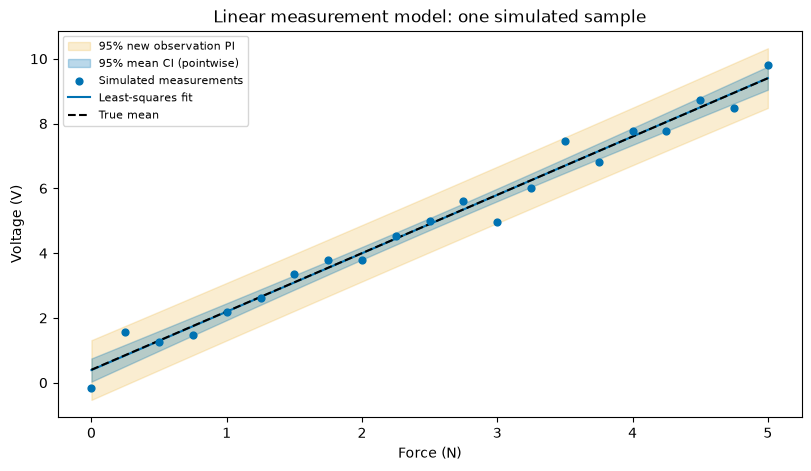

In [12]:
# 每行设计向量对应一个预测位置；逐行计算 aᵀ Cov(β) a。
grid_x = np.linspace(x.min(), x.max(), 160)
grid_design = np.column_stack([np.ones(grid_x.size), grid_x])
grid_mean = grid_design @ beta_hat
grid_mean_variance = np.sum(
    (grid_design @ coefficient_covariance) * grid_design, axis=1
)
mean_half_width = critical * np.sqrt(grid_mean_variance)
# 新观测的预测方差还包含残差方差，因此区间比均值区间更宽。
prediction_half_width = critical * np.sqrt(residual_variance + grid_mean_variance)

# 先画较宽的预测区间，再叠加均值区间，避免内层阴影被遮住。
fig, ax = plt.subplots(figsize=(8.0, 4.6), layout="constrained")
ax.fill_between(
    grid_x,
    grid_mean - prediction_half_width,
    grid_mean + prediction_half_width,
    color="#E69F00",
    alpha=0.18,
    label="95% new observation PI",
)
ax.fill_between(
    grid_x,
    grid_mean - mean_half_width,
    grid_mean + mean_half_width,
    color="#0072B2",
    alpha=0.27,
    label="95% mean CI (pointwise)",
)
ax.scatter(x, y, color="#0072B2", s=24, label="Simulated measurements", zorder=3)
ax.plot(grid_x, grid_mean, color="#0072B2", label="Least-squares fit")
ax.plot(
    grid_x, grid_design @ true_beta, color="black", linestyle="--", label="True mean"
)
ax.set(
    xlabel="Force (N)",
    ylabel="Voltage (V)",
    title="Linear measurement model: one simulated sample",
)
ax.legend(fontsize=8, loc="upper left")
plt.show()
# 阴影分清均值与单次测量的不确定性；真均值仅因教学模拟而可见。

## 8 重复抽样核对波动与覆盖率

固定同一组输入和真参数，独立生成 R=4000 组正态误差，每组 n=21 个。每列是一组完整实验；lstsq() 的二维右端项允许同时求出 4000 组参数。只增加重复次数 R 是为了观察估计程序，不会降低某一组 n=21 测量本身的标准误。

In [13]:
rng_repeat = np.random.default_rng(2502)
repeats = 4000
repeated_noise = rng_repeat.normal(0.0, sigma, size=(n, repeats))
repeated_y = (design @ true_beta)[:, None] + repeated_noise
repeated_beta = np.linalg.lstsq(design, repeated_y, rcond=None)[0]
repeated_residual = repeated_y - design @ repeated_beta
repeated_s2 = np.sum(repeated_residual**2, axis=0) / degrees
repeated_slope_se = np.sqrt(repeated_s2 * gram_inverse[1, 1])
covered_slope = np.abs(repeated_beta[1] - true_beta[1]) <= critical * repeated_slope_se
coverage = covered_slope.mean()
coverage_mcse = np.sqrt(coverage * (1 - coverage) / repeats)
print("重复参数数组形状：", repeated_beta.shape)  # 预期为 (2, 4000)。
print("斜率平均估计与真值：", repeated_beta[1].mean(), true_beta[1])  # 本次重复模拟的斜率均值约 1.79988 V/N，对照生成真值 1.8 V/N。
# 本次斜率模拟 SD 约 0.051339 V/N，理论 SE 约 0.050452 V/N。
print(
    "斜率模拟标准差与理论标准误：",
    repeated_beta[1].std(ddof=1),
    sigma * np.sqrt(gram_inverse[1, 1]),
)
print("斜率区间覆盖比例及其蒙特卡洛标准误：", coverage, coverage_mcse)  # 本次固定种子下约为 0.947 0.00354228。
# 覆盖比例在 0.95 附近波动；4000 次模拟不替代 t 分布结论的条件与推导。

重复参数数组形状： (2, 4000)
斜率平均估计与真值： 1.7998781836433555 1.8
斜率模拟标准差与理论标准误： 0.05133908824114429 0.050452497910951306
斜率区间覆盖比例及其蒙特卡洛标准误： 0.947 0.003542280338990692


同样可以在 x₀=2.5 N 检查两类输出区间。均值区间每次与固定的真实 μ₀ 比较；预测区间则每次与一个独立生成的新观测比较。若把均值区间错误地用于预测新观测，覆盖比例会显著改变。

In [14]:
repeated_mean = a0 @ repeated_beta
repeated_mean_se = np.sqrt(repeated_s2 * (a0 @ gram_inverse @ a0))
repeated_prediction_se = np.sqrt(repeated_s2 + repeated_mean_se**2)
true_mean0 = a0 @ true_beta
new_observations = true_mean0 + rng_repeat.normal(0.0, sigma, size=repeats)
# 本次固定种子下约为 0.94675。
print(
    "均值区间覆盖真实均值：",
    np.mean(np.abs(repeated_mean - true_mean0) <= critical * repeated_mean_se),
)
# 本次固定种子下约为 0.951。
print(
    "预测区间覆盖新观测：",
    np.mean(
        np.abs(repeated_mean - new_observations) <= critical * repeated_prediction_se
    ),
)
# 本次固定种子下约为 0.32975。
print(
    "误用均值区间覆盖新观测：",
    np.mean(np.abs(repeated_mean - new_observations) <= critical * repeated_mean_se),
)
# 前两行接近各自的标称覆盖率；第三行是在检查错误的用途。

均值区间覆盖真实均值： 0.94675
预测区间覆盖新观测： 0.951
误用均值区间覆盖新观测： 0.32975


下图只展示前 40 组实验的斜率区间：蓝色覆盖真值，橙色未覆盖。横轴单位为 V/N，纵轴是实验编号；这张图用来解释重复区间的含义，不用于替代全部 4000 组的数值汇总。

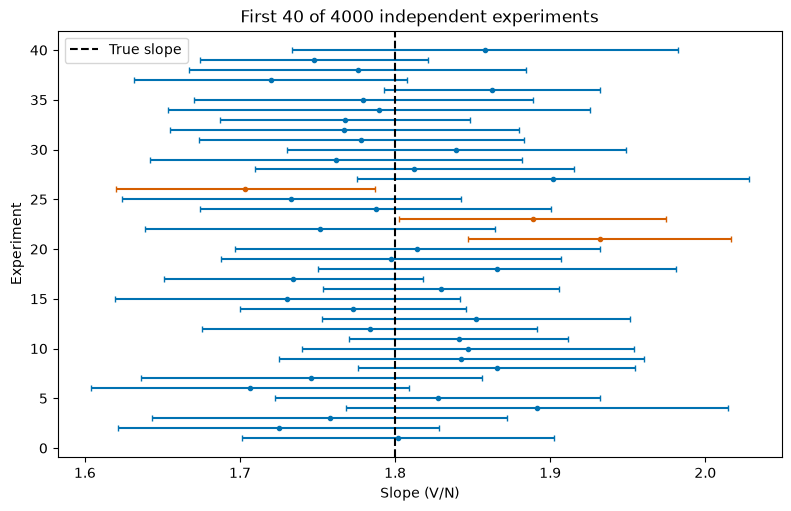

In [15]:
fig, ax = plt.subplots(figsize=(7.8, 5.0), layout="constrained")
# 仅展示前 40 次独立实验，颜色来自各区间是否覆盖真实斜率。
for i in range(40):
    color = "#0072B2" if covered_slope[i] else "#D55E00"
    # xerr 是临界值乘斜率标准误，也就是横向区间的半宽。
    ax.errorbar(
        repeated_beta[1, i],
        i + 1,
        xerr=critical * repeated_slope_se[i],
        fmt="o",
        markersize=3,
        color=color,
        capsize=2,
    )
ax.axvline(true_beta[1], color="black", linestyle="--", label="True slope")
ax.set(
    xlabel="Slope (V/N)",
    ylabel="Experiment",
    title="First 40 of 4000 independent experiments",
)
ax.legend(loc="upper left")
# 本次大部分区间穿过斜率真值 1.8 V/N 的竖线，少数不覆盖；覆盖率仍由全部 4000 次实验计算。
plt.show()
# 每条横线是一次实验的区间；未覆盖的区间属于程序允许的随机失败。

## 9 改变噪声和输入范围

直线模型中，Var(β̂₁)=σ²/Sxx。保持输入和样本量不变，噪声标准差加倍会使斜率标准误加倍。若把所有输入相对平均值的偏离缩小到原来的 1/5，Sxx 变为 1/25，斜率标准误变为 5 倍。

下面保持每个方案的 n 和 R 不变。为了清楚比较缩放效果，三个方案共享同一组标准正态误差数值；各方案内部的重复实验独立，方案之间有意配对，不能称为三组独立模拟。

In [16]:
design_cases = [
    ("baseline", x, sigma),
    ("double noise", x, 2 * sigma),
    ("narrow input", x.mean() + (x - x.mean()) / 5, sigma),
]
standard_noise = repeated_noise / sigma
for name, case_x, case_sigma in design_cases:
    case_design = np.column_stack([np.ones(n), case_x])
    case_y = (case_design @ true_beta)[:, None] + case_sigma * standard_noise
    case_beta = np.linalg.lstsq(case_design, case_y, rcond=None)[0]
    case_sxx = np.sum((case_x - case_x.mean()) ** 2)
    theoretical_se = case_sigma / np.sqrt(case_sxx)
    # 本次基线模拟 SD≈0.05134 V/N；双倍噪声约加倍，输入范围缩至 1/5 时约变为五倍。
    print(
        f"{name}: Sxx={case_sxx:.4f} N²，理论斜率 SE={theoretical_se:.6f} V/N，模拟 SD={case_beta[1].std(ddof=1):.6f} V/N"
    )
# 缩窄范围仍可能把局部平均输出拟合得很好，但斜率会更难确定。

baseline: Sxx=48.1250 N²，理论斜率 SE=0.050452 V/N，模拟 SD=0.051339 V/N
double noise: Sxx=48.1250 N²，理论斜率 SE=0.100905 V/N，模拟 SD=0.102678 V/N
narrow input: Sxx=1.9250 N²，理论斜率 SE=0.252262 V/N，模拟 SD=0.256695 V/N


若所有输入都等于 2.5 N，则只能识别 β₀+2.5β₁，不能分别识别两个参数。正规方程的唯一解和前面的区间公式不再适用。lstsq() 仍可返回一个最小范数解；“返回了系数”不表示参数已经被数据分别确定。

In [17]:
flat_design = np.column_stack([np.ones(5), np.full(5, 2.5)])
flat_y = np.array([4.8, 5.0, 4.9, 5.1, 4.7])
flat_beta, _, flat_rank, _ = np.linalg.lstsq(flat_design, flat_y, rcond=None)
alternative_beta = flat_beta + np.array([-2.5, 1.0])
print("设计矩阵秩：", flat_rank)  # 预期为 1。
print("两个不同参数：", flat_beta, alternative_beta)  # 预期约为 [0.675862 1.68966] [-1.82414 2.68966]。
# 预期接近 0；本次计算为 0。
print(
    "两组拟合值的最大差：",
    np.max(np.abs(flat_design @ flat_beta - flat_design @ alternative_beta)),
)
# 改变截距和斜率却保持 β0+2.5β1 不变，说明数据无法区分这些参数。

设计矩阵秩： 1
两个不同参数： [0.67586207 1.68965517] [-1.82413793  2.68965517]
两组拟合值的最大差： 0.0


## 10 检查模型之外的误差

数值求解误差、随机测量误差和模型偏差是三件事。现在给平均输出增加 c(x−x_c)²，其中 c=0.35 V/N²、x_c=2.5 N，并保留同一次噪声。用直线拟合时，即使正规方程残差很小，也没有恢复原来的曲线关系。

下图比较正确直线模型与遗漏二次项时的残差。系统弯曲是重新检查平均函数的信号；一张看似随机的残差图也不能证明所有统计假设成立。

错误直线模型的正规方程残差： 8.881784197001252e-15
两种数据的残差平方和： 3.129069681906943 13.8637071852077


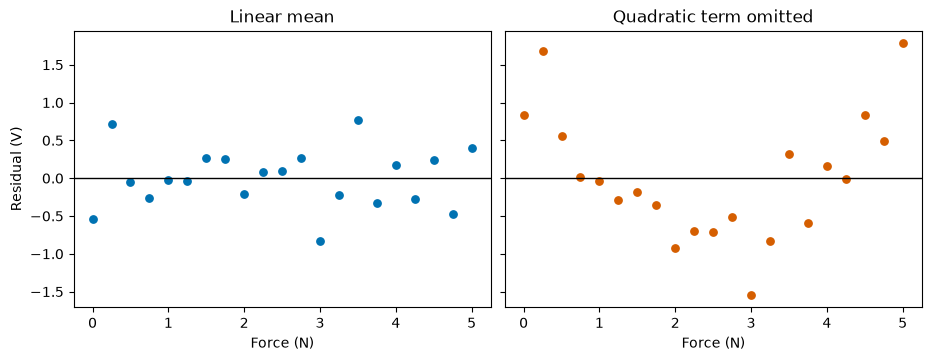

In [18]:
curved_y = design @ true_beta + 0.35 * (x - 2.5) ** 2 + noise
curved_beta = np.linalg.lstsq(design, curved_y, rcond=None)[0]
curved_residual = curved_y - design @ curved_beta
print("错误直线模型的正规方程残差：", np.max(np.abs(design.T @ curved_residual)))  # 本次数值约为 8.9e-15。
print("两种数据的残差平方和：", residual @ residual, curved_residual @ curved_residual)  # 本次固定种子下约为 3.12907 13.8637。

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.5), sharey=True, layout="constrained")
for ax, values, title, color in zip(
    axes,
    [residual, curved_residual],
    ["Linear mean", "Quadratic term omitted"],
    ["#0072B2", "#D55E00"],
):
    ax.scatter(x, values, s=28, color=color)
    ax.axhline(0, color="black", linewidth=1)
    ax.set(xlabel="Force (N)", title=title)
axes[0].set_ylabel("Residual (V)")
plt.show()
# 右图出现弯曲结构；把这类偏差都解释为独立正态噪声会误用区间条件。

整理本次结论时，应同时保留输入范围、生成条件、估计对象、单位和区间含义。下面只报告正确直线模型那一次样本的结果；真实仪器能否采用该模型，需要实际数据和领域条件支持。

In [19]:
print(f"教学模拟：n={n}，固定输入范围 [{x.min():.1f}, {x.max():.1f}] N。")  # 输出本例固定的设计：n=21，输入范围 [0, 5] N。
print("假设：输入无误差；平均输出为直线；测量误差独立、同方差且正态。")
# 本次斜率估计约 1.803 V/N，95% 区间约 [1.680, 1.925] V/N。
print(
    f"斜率估计 {beta_hat[1]:.3f} V/N，单参数 95% CI [{coefficient_intervals[1, 0]:.3f}, {coefficient_intervals[1, 1]:.3f}] V/N。"
)
print(f"在 x0={x0:.1f} N，平均输出估计 {mean_at_x0:.3f} V。")  # 在固定位置 x0=2.5 N，本次平均输出估计约 4.897 V。
print(f"平均输出 95% CI [{mean_interval[0]:.3f}, {mean_interval[1]:.3f}] V。")  # 本次平均输出的 95% 区间约为 [4.712, 5.082] V。
# 本次新测量的 95% 预测区间约为 [4.028, 5.766] V。
print(f"新测量 95% PI [{prediction_interval[0]:.3f}, {prediction_interval[1]:.3f}] V。")
# 计算保留全精度，显示时才舍入；这些值不是现实传感器的校准报告。

教学模拟：n=21，固定输入范围 [0.0, 5.0] N。
假设：输入无误差；平均输出为直线；测量误差独立、同方差且正态。
斜率估计 1.803 V/N，单参数 95% CI [1.680, 1.925] V/N。
在 x0=2.5 N，平均输出估计 4.897 V。
平均输出 95% CI [4.712, 5.082] V。
新测量 95% PI [4.028, 5.766] V。


## 11 选学：中心化二维数据与 PCA

主成分分析（principal component analysis，PCA）寻找数据变化最大的正交方向。这里改用 6 个二维位置点，两坐标都以 cm 为单位，没有预先指定的响应变量。它最小化到子空间的正交重构误差，与前面固定输入后沿输出方向拟合的任务不同。

设数据矩阵 D∈ℝᵐˣ²，m=6，每行一个点。各列减去均值后得到 Z，样本协方差矩阵为 Cₚ=ZᵀZ/(m−1)，形状 2×2、单位 cm²。中心化去掉位置偏移，不会把每列缩放成单位方差；量纲不同或尺度不可比较时，需先明确缩放的意义。

In [20]:
points = np.array(
    [[0.0, 0.0], [1.0, 1.0], [2.0, 1.0], [3.0, 3.0], [4.0, 3.0], [5.0, 5.0]]
)
m = points.shape[0]
point_mean = points.mean(axis=0)
centered_points = points - point_mean
pca_covariance = centered_points.T @ centered_points / (m - 1)
print("中心位置（cm）：", point_mean)  # 预期约为 [2.5 2.16667]。
print("中心化后的列均值：", centered_points.mean(axis=0))  # 预期中心化后的两列均值接近 0；本次最大绝对值约 7.4e-17。
print("数据与协方差的形状：", centered_points.shape, pca_covariance.shape)  # 预期为 (6, 2) (2, 2)。
print("样本协方差（cm²）：\n", pca_covariance)  # 预期约为 [[3.5 3.3 ] [3.3 3.36667]]。
# 两列使用相同单位；本例只中心化，不额外标准化。

中心位置（cm）： [2.5        2.16666667]
中心化后的列均值： [0.00000000e+00 7.40148683e-17]
数据与协方差的形状： (6, 2) (2, 2)
样本协方差（cm²）：
 [[3.5        3.3       ]
 [3.3        3.36666667]]


取单位向量 v∈ℝ²，将各点投影到该方向，得分 t=Zv，形状 m×1、单位 cm。因 Z 已中心化，得分的样本方差为

$$\frac{\|Zv\|_2^2}{m-1}=v^TC_pv,\qquad v^Tv=1。$$

对实对称 Cₚ 做正交特征分解，将特征值按 λ₁≥λ₂≥0 排列。写 v=c₁v₁+c₂v₂ 后，上式为 λ₁c₁²+λ₂c₂²≤λ₁，因为 c₁²+c₂²=1。因此最大特征值对应的单位特征向量给出第一主方向。eigh() 默认升序返回特征值，代码需要同步调整向量列顺序。

In [21]:
eigenvalues, eigenvectors = np.linalg.eigh(pca_covariance)
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]
direction = eigenvectors[:, 0]
scores = centered_points @ direction
print("降序特征值（cm²）：", eigenvalues)  # 预期约为 [6.73401 0.13266 ]。
print("第一方向与长度：", direction, np.linalg.norm(direction))  # 预期约为 [-0.714212 -0.699929] 1。
print("得分的样本方差：", scores.var(ddof=1))  # 预期约为 6.73401。
print("第一主成分保留的样本方差比例：", eigenvalues[0] / eigenvalues.sum())  # 预期约为 0.980681。
# 得分方差等于最大特征值；比例描述这份数据的方差，不是预测准确率。

降序特征值（cm²）： [6.73400667 0.13266   ]
第一方向与长度： [-0.71421212 -0.69992932] 1.0000000000000002
得分的样本方差： 6.734006665313409
第一主成分保留的样本方差比例： 0.9806805823271951


## 12 选学：SVD、投影与重构误差

对中心化矩阵做薄 SVD：Z=UΣVᵀ。这里 U 为 m×2，Σ 为 2×2，V 为 2×2，奇异值 s₁≥s₂≥0。由于 UᵀU=I₂，

$$C_p=\frac{1}{m-1}V\Sigma^2V^T,\qquad
\lambda_j=\frac{s_j^2}{m-1}。$$

所以第一右奇异向量与第一主方向张成相同直线。单位方向 v 和 −v 都合法；应比较投影矩阵 vvᵀ，而不是要求两个库结果逐项同号。

In [22]:
left_vectors, pca_singular, right_transpose = np.linalg.svd(
    centered_points, full_matrices=False
)
svd_direction = right_transpose[0]
projection_eigen = np.outer(direction, direction)
projection_svd = np.outer(svd_direction, svd_direction)
print("薄 SVD 的形状：", left_vectors.shape, pca_singular.shape, right_transpose.shape)  # 预期为 (6, 2) (2,) (2, 2)。
print("s²/(m-1) 与协方差特征值：", pca_singular**2 / (m - 1), eigenvalues)  # 预期约为 [6.73401 0.13266 ] [6.73401 0.13266 ]。
print("两个方向的绝对内积：", abs(direction @ svd_direction))  # 预期约为 1。
print("投影矩阵最大差：", np.max(np.abs(projection_eigen - projection_svd)))  # 本次数值约为 4.4e-16。
# 向量可能反号，但当前数据的第一主子空间一致。

薄 SVD 的形状： (6, 2) (2,) (2, 2)
s²/(m-1) 与协方差特征值： [6.73400667 0.13266   ] [6.73400667 0.13266   ]
两个方向的绝对内积： 1.0
投影矩阵最大差： 4.440892098500626e-16


保留一个方向后，中心化重构为 Ẑ=Zvvᵀ，原坐标重构为 Ẑ 加各列均值。平方重构误差为 ∥Z−Ẑ∥²F，其中 Frobenius 范数平方是所有元素平方之和。

对本例的两个正交奇异方向，删除第二项得到 ∥Z−Ẑ∥²F=s₂²=(m−1)λ₂。按正交分解，这也是全部中心化平方长度减去保留得分的平方长度；最大化保留方差就等价于最小化该误差。

In [23]:
# 先在中心化坐标中投影，再加回均值，还原到原始位置单位。
reconstruction_eigen = centered_points @ projection_eigen + point_mean
reconstruction_svd = centered_points @ projection_svd + point_mean
reconstruction_error = np.sum((points - reconstruction_eigen) ** 2)
# 本次数值约为 1.8e-15。
print(
    "两种原坐标重构的最大差：",
    np.max(np.abs(reconstruction_eigen - reconstruction_svd)),
)
# 把同一平方重构误差分别与舍弃奇异值、协方差特征值的表达式核对。
# 预期约为 0.6633 0.6633 0.6633。
print(
    "平方重构误差、s2²、(m-1)λ2：",
    reconstruction_error,
    pca_singular[1] ** 2,
    (m - 1) * eigenvalues[1],
)
# 本次数值约为 1.2e-15。
print(
    "残差沿保留方向的最大投影：",
    np.max(np.abs((points - reconstruction_eigen) @ direction)),
)
# 外积中两个负号相消，说明方向反号不改变投影矩阵。
# 预期接近 0；本次计算为 0。
print(
    "翻转方向后的投影最大差：",
    np.max(np.abs(np.outer(-direction, -direction) - projection_eigen)),
)
# 重构误差单位 cm²；方向反号不改变投影，重构残差与保留方向正交。

两种原坐标重构的最大差： 1.7763568394002505e-15
平方重构误差、s2²、(m-1)λ2： 0.6633000067662961 0.6633000067662965 0.6633000067662986
残差沿保留方向的最大投影： 1.2484915087563689e-15
翻转方向后的投影最大差： 0.0


图中的连线从原始点指向一维重构点，表示被舍弃的正交分量。两轴保持相同几何比例，才能正确观察投影的垂直关系。

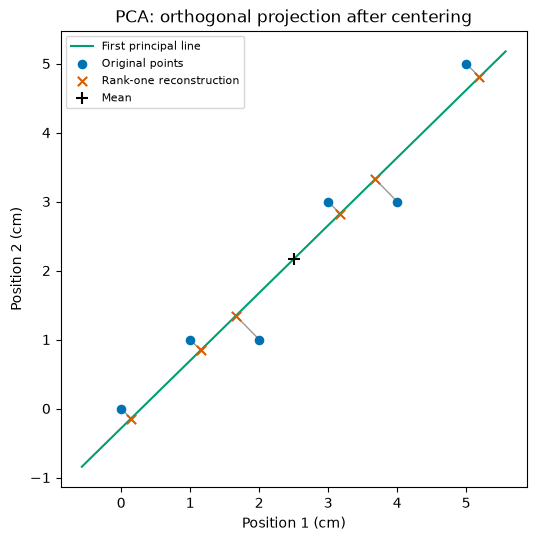

In [24]:
fig, ax = plt.subplots(figsize=(6.3, 5.3), layout="constrained")
# 每条灰线连接原始点与其重构点，显示二维空间中的投影残差。
for original, reconstructed in zip(points, reconstruction_eigen):
    ax.plot(
        [original[0], reconstructed[0]],
        [original[1], reconstructed[1]],
        color="#999999",
        linewidth=1,
    )
# 两个端点由均值沿主方向移动得到，主线因此经过样本均值。
line_coordinates = point_mean + np.array([-4.3, 4.3])[:, None] * direction
ax.plot(
    line_coordinates[:, 0],
    line_coordinates[:, 1],
    color="#009E73",
    label="First principal line",
)
ax.scatter(
    points[:, 0], points[:, 1], s=35, color="#0072B2", label="Original points", zorder=3
)
# 重构点用叉号与原始点区分，最后标出作为中心的均值。
ax.scatter(
    reconstruction_eigen[:, 0],
    reconstruction_eigen[:, 1],
    s=45,
    marker="x",
    color="#D55E00",
    label="Rank-one reconstruction",
    zorder=4,
)
ax.scatter(*point_mean, marker="+", s=85, color="black", label="Mean", zorder=5)
ax.set(
    xlabel="Position 1 (cm)",
    ylabel="Position 2 (cm)",
    title="PCA: orthogonal projection after centering",
    aspect="equal",
)
ax.legend(fontsize=8, loc="upper left")
# 预期重构叉号落在经过均值的主直线上，灰色残差线与该直线垂直。
plt.show()
# 灰线是重构残差；PCA 同时考虑两个方向的坐标差。

## 13 选学：重复特征值下的非唯一性

若 Cₚ=λI₂ 且 λ>0，则任意单位 v 都满足 vᵀCₚv=λ。一维主方向不再唯一，不同方向会得到不同重构，但平方重构误差相同。这个现象比反号更强：反号保持同一条直线，而这里可以选择不同的直线。

用 (±1,0)、(0,±1) 四个中心化点举例，Cₚ=(2/3)I₂。比较横轴方向与 45° 方向。若保留整个二维空间，则无论使用哪组正交基，投影都恢复原始点。

In [25]:
# 四个点的均值已为零，用相同数据比较坐标轴与对角线两个投影方向。
isotropic_points = np.array([[1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0]])
isotropic_covariance = isotropic_points.T @ isotropic_points / 3
axis_direction = np.array([1.0, 0.0])
diagonal_direction = np.array([1.0, 1.0]) / np.sqrt(2)
# 两个单位方向分别构造一维投影矩阵；比较重构位置和误差这两个不同量。
axis_reconstruction = isotropic_points @ np.outer(axis_direction, axis_direction)
diagonal_reconstruction = isotropic_points @ np.outer(
    diagonal_direction, diagonal_direction
)
# 预期约为 [[0.666667 0. ] [0. 0.666667]] [0.666667 0.666667]。
print(
    "协方差与特征值：\n", isotropic_covariance, np.linalg.eigvalsh(isotropic_covariance)
)
# 预期约为 0.5。
print(
    "两种一维重构的最大差：",
    np.max(np.abs(axis_reconstruction - diagonal_reconstruction)),
)
# 预期为 2 2。
print(
    "两个平方重构误差：",
    np.sum((isotropic_points - axis_reconstruction) ** 2),
    np.sum((isotropic_points - diagonal_reconstruction) ** 2),
)
# 误差都为 2 cm²，重构却不同；不能把某一次返回的基解释为唯一真实方向。

协方差与特征值：
 [[0.66666667 0.        ]
 [0.         0.66666667]] [0.66666667 0.66666667]
两种一维重构的最大差： 0.5000000000000001
两个平方重构误差： 2.0 2.0


## 本章小结

（1）先明确变量、单位、设计范围和误差机制，再选择目标函数。设计矩阵的秩决定参数能否分别确定。

（2）最小二乘的代数解、库结果、正规方程残差与梯度差分分别核对不同环节。计算一致不证明模型假设正确。

（3）参数标准误、平均输出区间和新测量预测区间针对不同对象；区间覆盖结论依赖抽样和分布条件。

（4）重复模拟观察程序的波动，改变噪声或输入范围解释精度来自哪里；系统模型偏差需要另外处理。

（5）选学 PCA 用中心化、协方差特征分解和 SVD 描述同一投影问题。反号不影响子空间，重复特征值可能让最优降维子空间也不唯一。

理解自查：为什么正规方程残差几乎为零时，斜率仍可能不准确？为什么同样为 95% 的均值区间和预测区间宽度不同？

## 练习

（1）给五点小例子增加“截距必须为零”的约束。只使用输入这一列拟合斜率，比较两种模型的平方残差和。解释增加约束后目标最小值为什么不能变小，以及物理上何时才有理由使用该约束。

In [26]:
exercise_x = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
exercise_y = np.array([1.1, 2.9, 5.2, 6.8, 9.0])
# 分别建立一列和两列的设计矩阵，核对拟合值与平方残差和。
# 检查：受约束结果的平方残差和不小于含截距模型。

（2）把模拟输入从 N 改用 mN 表示，即所有 x 乘以 1000，输出仍以 V 表示。重新拟合并计算参数区间，核对截距、斜率、斜率标准误和拟合输出如何变化。用单位换算解释结果，不直接比较不同单位下的系数大小。

In [27]:
exercise_millinewtons = x * 1000
exercise_voltage = y.copy()
# 在相同观测上换算输入；先预测斜率和斜率标准误的缩放因子。
# 检查：两组拟合电压在舍入容差内一致。

（3）把每次误差的标准差改为 0.1+0.15xᵢ V。重复模拟后仍机械套用共同方差的斜率区间，观察覆盖率。指出哪项假设改变；即使一次覆盖比例恰好接近 95%，能否因此宣称原来的精确 t 结论仍成立？

In [28]:
exercise_rng = np.random.default_rng(2523)
exercise_sigma = 0.1 + 0.15 * x
exercise_repeats = 4000
# 生成形状 (n, exercise_repeats) 的误差，逐组拟合并估计覆盖比例。
# 报告模拟条件、覆盖比例与蒙特卡洛标准误，并区分观察与理论保证。

（4）选学：对四个等方差方向点只保留一个主成分，再把第一坐标乘以 2。先判断最大特征值是否仍重复，再比较方向与重构误差。说明这种缩放改变了什么误差度量；如果只改变表示单位而没有改变问题目标，直接做同样 PCA 是否合理？

In [29]:
exercise_points = np.array([[1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0]])
exercise_scaled_points = exercise_points * np.array([2.0, 1.0])
# 对两组数据分别中心化、分解协方差、投影并计算平方重构误差。
# 检查：缩放后两特征值不再相同；解释比较误差时使用的坐标尺度。

## 练习提示与解析

以下对应练习（2）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：先让换单位前后的拟合电压表达式相等。

提示 2：斜率和它的标准误具有相同单位；残差、电压尺度和自由度不随输入单位改变。

### 练习（2）参考解析

记新输入为 $x'=1000x$。由 $\widehat\beta_0+\widehat\beta_1x=\widehat\beta_0+(\widehat\beta_1/1000)x'$，新截距不变，新斜率为原值的 1/1000，单位由 V/N 变为 V/mN。

输入离均差平方和放大 $10^6$ 倍，残差标准差不变，所以斜率标准误缩小为 1/1000，斜率区间的两个端点也都除以 1000；截距标准误与区间不变。两套拟合电压应在舍入误差内相同。参数数字变小是单位改变，并不表示关系变弱或估计更准确。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| NIST/SEMATECH | [§4.2.1 建模假设](https://www.itl.nist.gov/div898/handbook/pmd/section2/pmd21.htm)，零均值、同方差、正态误差与输入无误差条件；[§4.4.3.1 Least Squares](https://www.itl.nist.gov/div898/handbook/pmd/section4/pmd431.htm)，直线估计式、残差标准差和自由度；[§4.5.1.1 平均响应区间](https://www.itl.nist.gov/div898/handbook/pmd/section5/pmd511.htm)，Computing / Interpretation of Confidence Intervals；[§4.5.1.2 新观测预测](https://www.itl.nist.gov/div898/handbook/pmd/section5/pmd512.htm)，新观测独立性、方差相加和预测区间；[§4.4.4 残差分析](https://www.itl.nist.gov/div898/handbook/pmd/section4/pmd44.htm)，模型充分性与数值拟合的区别。测量数据、重复模拟与条件变化例子为本章另行构造。 |
| StatLect 作者网站 | Marco Taboga，[The normal linear regression model](https://www.statlect.com/fundamentals-of-statistics/normal-linear-regression-model)，Assumptions、Distribution of the OLS estimator、Estimation of the variance of the error terms、Estimation of the covariance matrix：满秩、正态误差、参数协方差、残差自由度与独立性。 |
| MMiDS 作者教材 | Sébastien Roch，[§3.5 梯度下降](https://mmids-textbook.github.io/chap03_opt/05_gd/roch-mmids-opt-gd.html)，开篇 Least Squares 例子的二次目标、梯度和正规方程；[§4.5.1 PCA](https://mmids-textbook.github.io/chap04_svd/05_pca/roch-mmids-svd-pca.html)，中心化、得分方差与协方差特征向量及右奇异向量的对应；[§4.3.1 最佳近似子空间](https://mmids-textbook.github.io/chap04_svd/03_svd/roch-mmids-svd-svd.html)，正交投影、方差最大化与非唯一性；[§4.6.2 低秩近似](https://mmids-textbook.github.io/chap04_svd/06_further/roch-mmids-svd-further.html)，截断重构的 Frobenius 误差公式。 |
| NumPy 官方文档 | NumPy 2.5：[linalg.lstsq](https://numpy.org/doc/2.5/reference/generated/numpy.linalg.lstsq.html)，最小范数解、rcond、二维右端项与返回形状；[linalg.solve](https://numpy.org/doc/2.5/reference/generated/numpy.linalg.solve.html)，方阵方程求解；[linalg.eigh](https://numpy.org/doc/2.5/reference/generated/numpy.linalg.eigh.html)，实对称输入、升序特征值和列特征向量；[linalg.svd](https://numpy.org/doc/2.5/reference/generated/numpy.linalg.svd.html)，薄分解、奇异值顺序及右奇异向量；[Generator.normal](https://numpy.org/doc/2.5/reference/random/generated/numpy.random.Generator.normal.html)，loc、scale 与 size；[随机流兼容条件](https://numpy.org/doc/stable/reference/random/compatibility.html)。 |
| SciPy 官方文档 | SciPy 1.18：[stats.linregress](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html)，系数、标准误及 Examples 中 n−2 自由度的 t 区间；[stats.t](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html)，df 与 ppf；[differentiate.derivative](https://docs.scipy.org/doc/scipy/reference/generated/scipy.differentiate.derivative.html)，有限差分和 Notes 中步长、舍入与消减条件；本章直接编写中心差分核对二次目标。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.fill_between](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html)，区间阴影的两条边界；[Axes.errorbar](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.errorbar.html)，xerr 表示水平误差条半宽；[Axes.set_aspect](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_aspect.html)，等比例几何显示。 |